In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/diabetes.csv")

df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (253680, 22)

Column names:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Diabetes_binary']

Data types:
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64
dtyp

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-null  int64


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


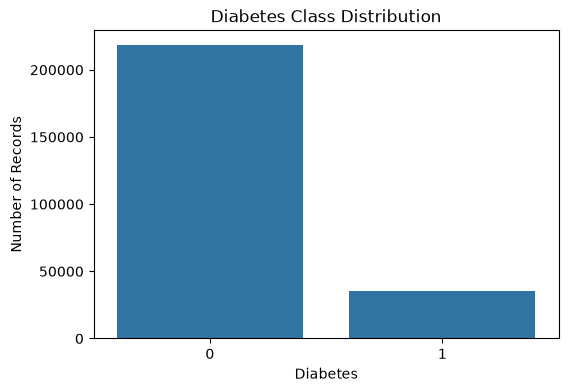

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Diabetes_binary")

plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Number of Records")

plt.show()

In [7]:
class_percentages = df["Diabetes_binary"].value_counts(normalize=True) * 100

print(class_percentages)

Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 24206


In [9]:
df_clean = df.drop_duplicates().copy()

print("Original shape:", df.shape)
print("After removing duplicates:", df_clean.shape)

print("\nRows removed:", len(df) - len(df_clean))

print("\nClass distribution after removing duplicates:")
print(df_clean["Diabetes_binary"].value_counts())

print("\nClass percentages after removing duplicates:")
print(
    df_clean["Diabetes_binary"]
    .value_counts(normalize=True) * 100
)

Original shape: (253680, 22)
After removing duplicates: (229474, 22)

Rows removed: 24206

Class distribution after removing duplicates:
Diabetes_binary
0    194377
1     35097
Name: count, dtype: int64

Class percentages after removing duplicates:
Diabetes_binary
0    84.705457
1    15.294543
Name: proportion, dtype: float64


In [10]:
correlation = df_clean.corr(numeric_only=True)["Diabetes_binary"].sort_values(
    ascending=False
)

print(correlation)

Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64


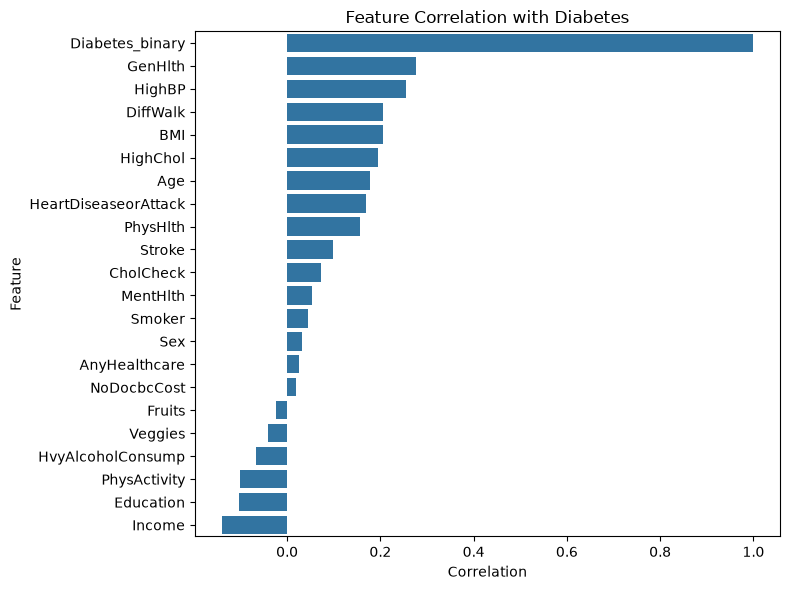

In [11]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=correlation.values,
    y=correlation.index
)

plt.title("Feature Correlation with Diabetes")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [12]:
correlation

Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64

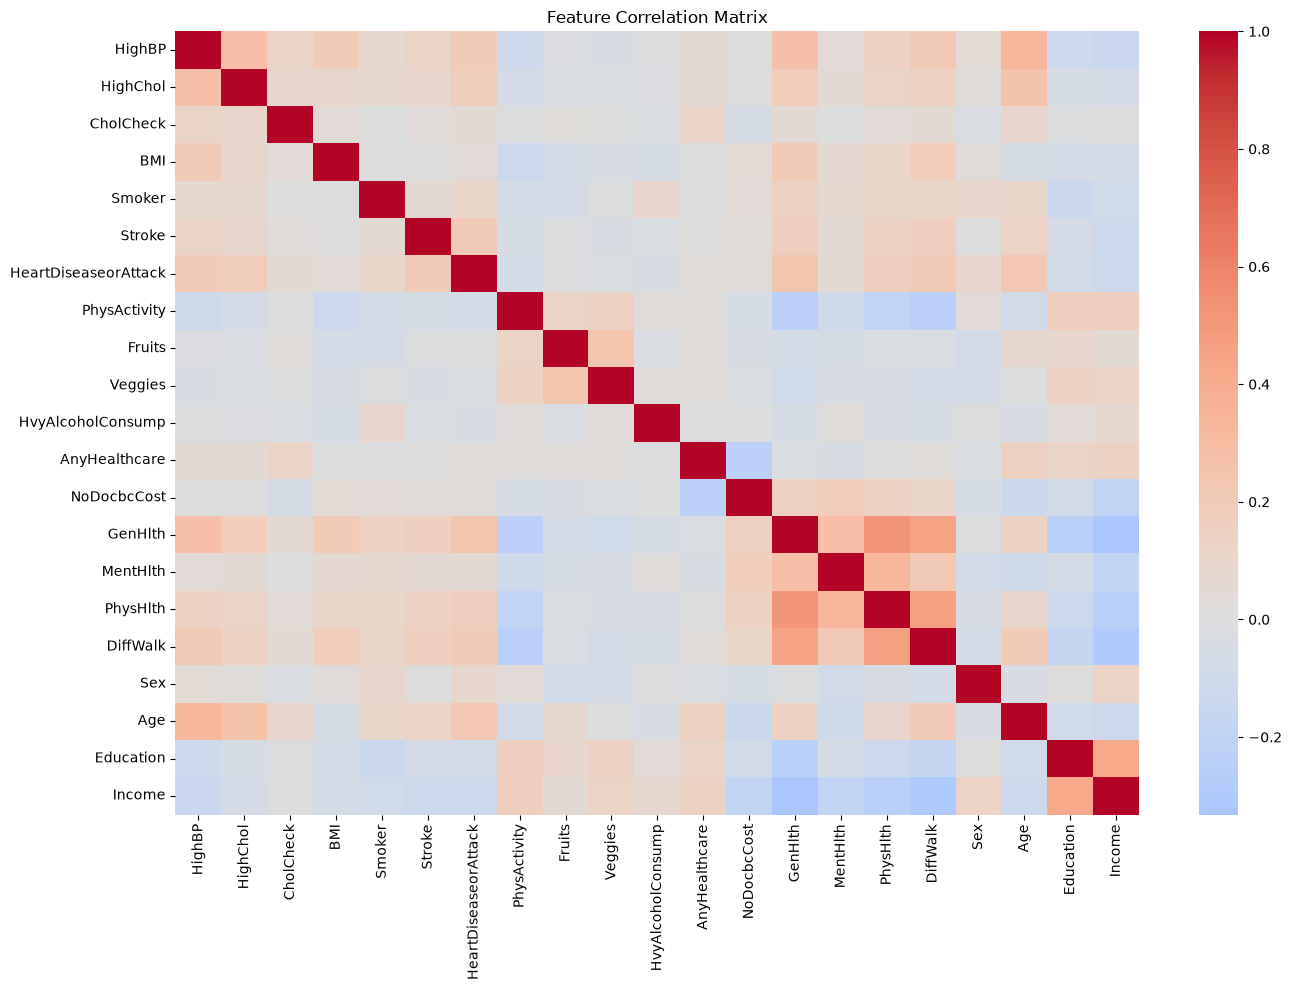

In [13]:
feature_corr = df_clean.drop(columns="Diabetes_binary").corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    feature_corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [14]:
X = df_clean.drop(columns="Diabetes_binary")
y = df_clean["Diabetes_binary"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (229474, 21)
y shape: (229474,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (183579, 21)
Test set: (45895, 21)

Training target distribution:
Diabetes_binary
0    0.847052
1    0.152948
Name: proportion, dtype: float64

Test target distribution:
Diabetes_binary
0    0.847064
1    0.152936
Name: proportion, dtype: float64


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.7143043904564768
Precision: 0.3182604545725705
Recall   : 0.7600797834449352
F1 Score : 0.4486586493987049
ROC-AUC  : 0.8105827554685582

Confusion Matrix:
[[27448 11428]
 [ 1684  5335]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.71      0.81     38876
           1       0.32      0.76      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.73      0.63     45895
weighted avg       0.85      0.71      0.75     45895



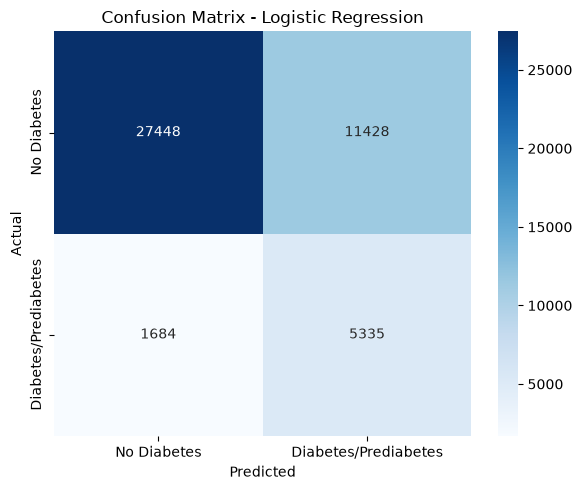

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes/Prediabetes"],
    yticklabels=["No Diabetes", "Diabetes/Prediabetes"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [19]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.20, 0.81, 0.05)

results = []

for threshold in thresholds:
    predictions = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1 Score
0,0.20,0.209516,0.971791,0.344713
1,0.25,0.227165,0.953127,0.366887
2,0.30,0.245461,0.928337,0.388262
3,0.35,0.263228,0.895854,0.406898
4,0.40,0.281199,0.858099,0.423588
5,0.45,0.299506,0.811939,0.437594
6,0.50,0.318260,0.760080,0.448659
7,0.55,0.340092,0.702522,0.458314
8,0.60,0.365488,0.641829,0.465753
9,0.65,0.392093,0.566605,0.463466


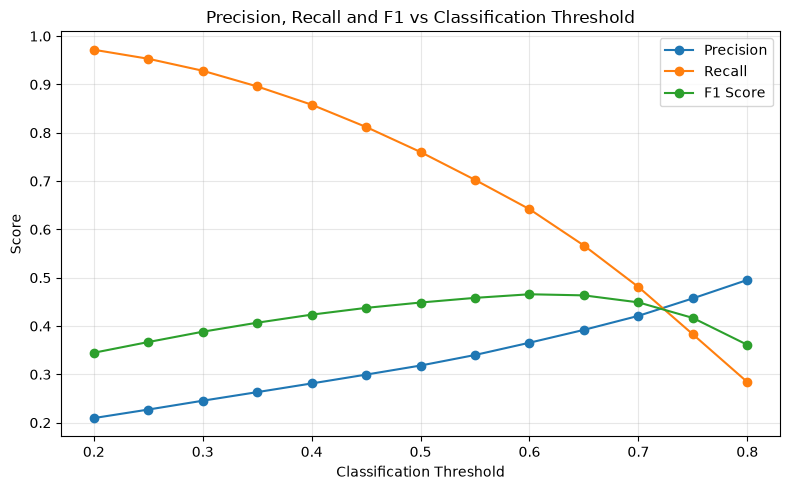

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/pritikarajendran/Documents/diabetes-risk-prediction/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <09B43001-8527-34F6-AAE4-B97DA8A6CBC0> /Users/pritikarajendran/Documents/diabetes-risk-prediction/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System

In [1]:
from xgboost import XGBClassifier

print("XGBoost import successful!")

XGBoost import successful!


In [2]:
from xgboost import XGBClassifier

print("XGBoost import successful!")


XGBoost import successful!


In [3]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

NameError: name 'X_train' is not defined

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

NameError: name 'X' is not defined

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

NameError: name 'df' is not defined

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("data/diabetes.csv")

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Separate features and target
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Dataset shape:", df.shape)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/diabetes.csv'

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("../data/diabetes.csv")

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Separate features and target
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Dataset shape:", df.shape)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Dataset shape: (229474, 22)
Training set: (183579, 21)
Test set: (45895, 21)


In [8]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("XGBoost Results")
print("----------------")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
----------------
Accuracy : 0.8554744525547445
Precision: 0.5929672447013488
Recall   : 0.17538110842000285
F1 Score : 0.2706981858163826
ROC-AUC  : 0.8192999628791142

Confusion Matrix:
[[38031   845]
 [ 5788  1231]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     38876
           1       0.59      0.18      0.27      7019

    accuracy                           0.86     45895
   macro avg       0.73      0.58      0.60     45895
weighted avg       0.83      0.86      0.82     45895



In [10]:
from xgboost import XGBClassifier

xgb_balanced = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5.54,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_balanced.fit(X_train, y_train)

print("Balanced XGBoost model trained successfully!")

Balanced XGBoost model trained successfully!


In [11]:
y_pred_balanced = xgb_balanced.predict(X_test)
y_prob_balanced = xgb_balanced.predict_proba(X_test)[:, 1]

print("Balanced XGBoost Results")
print("-----------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall   :", recall_score(y_test, y_pred_balanced))
print("F1 Score :", f1_score(y_test, y_pred_balanced))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Balanced XGBoost Results
-----------------------
Accuracy : 0.7120165595380761
Precision: 0.31946871723173714
Recall   : 0.7813078786151874
F1 Score : 0.4535042381641513
ROC-AUC  : 0.8182879357297225

Confusion Matrix:
[[27194 11682]
 [ 1535  5484]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.70      0.80     38876
           1       0.32      0.78      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895



In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=pd.DataFrame({
        "Probability": y_prob_balanced,
        "Actual": y_test.values
    }),
    x="Probability",
    hue="Actual",
    bins=30,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Predicted Risk Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


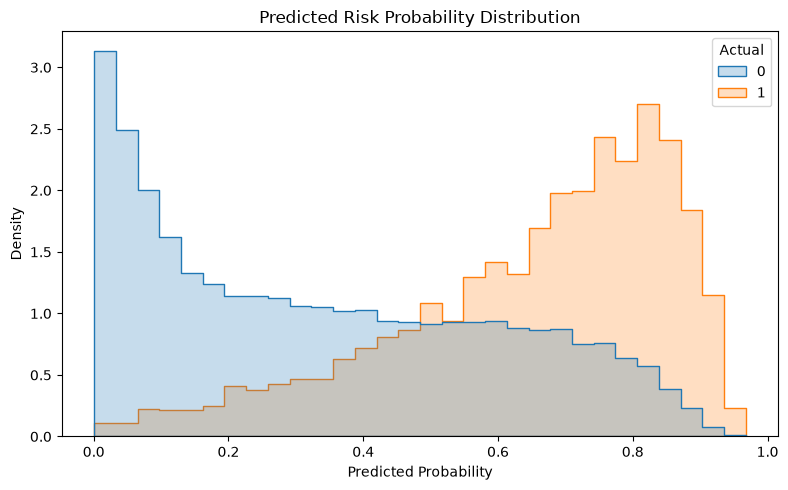

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=pd.DataFrame({
        "Probability": y_prob_balanced,
        "Actual": y_test.values
    }),
    x="Probability",
    hue="Actual",
    bins=30,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Predicted Risk Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")

plt.tight_layout()
plt.show()


In [15]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "Balanced XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_balanced)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_balanced)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_balanced)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_balanced)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_balanced)
    ]
})

model_results

NameError: name 'y_pred' is not defined

In [16]:
# Recreate predictions for all 3 models

# Logistic Regression
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Standard XGBoost
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Balanced XGBoost
y_pred_balanced = xgb_balanced.predict(X_test)
y_prob_balanced = xgb_balanced.predict_proba(X_test)[:, 1]

print("Predictions recreated successfully!")

NameError: name 'logistic_model' is not defined

In [17]:
# ==========================================
# REBUILD DATA + TRAIN ALL 3 MODELS
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

# 1. Load dataset
df = pd.read_csv("../data/diabetes.csv")

# 2. Remove duplicate rows
df_clean = df.drop_duplicates().copy()

print("Clean dataset:", df_clean.shape)

# 3. Separate features and target
X = df_clean.drop(columns="Diabetes_binary")
y = df_clean["Diabetes_binary"]

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

# ==========================================
# 5. LOGISTIC REGRESSION
# ==========================================

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# ==========================================
# 6. STANDARD XGBOOST
# ==========================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ==========================================
# 7. BALANCED XGBOOST
# ==========================================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_balanced = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_balanced.fit(X_train, y_train)

y_pred_balanced = xgb_balanced.predict(X_test)
y_prob_balanced = xgb_balanced.predict_proba(X_test)[:, 1]

print("\nAll 3 models trained successfully!")
print("scale_pos_weight:", round(scale_pos_weight, 2))

Clean dataset: (229474, 22)
Training: (183579, 21)
Testing: (45895, 21)

All 3 models trained successfully!
scale_pos_weight: 5.54


In [18]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "Balanced XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_balanced)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_balanced)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_balanced)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_balanced)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_balanced)
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7143,0.3183,0.7601,0.4487,0.8106
1,XGBoost,0.8555,0.5930,0.1754,0.2707,0.8193
2,Balanced XGBoost,0.7118,0.3192,0.7806,0.4531,0.8185


In [19]:
thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:

    predictions = (y_prob_balanced >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(3)

,Threshold,Precision,Recall,F1 Score
0,0.20,0.221,0.962,0.359
1,0.25,0.234,0.942,0.375
2,0.30,0.250,0.921,0.393
3,0.35,0.267,0.899,0.411
4,0.40,0.284,0.866,0.428
5,0.45,0.301,0.827,0.442
6,0.50,0.319,0.781,0.453
7,0.55,0.342,0.729,0.466
8,0.60,0.367,0.664,0.473
9,0.65,0.397,0.594,0.476


In [20]:
from sklearn.metrics import confusion_matrix

threshold = 0.65

y_pred_final = (y_prob_balanced >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

print("Threshold:", threshold)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Threshold: 0.65

Confusion Matrix:
[[32552  6324]
 [ 2853  4166]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88     38876
           1       0.40      0.59      0.48      7019

    accuracy                           0.80     45895
   macro avg       0.66      0.72      0.68     45895
weighted avg       0.84      0.80      0.82     45895



In [21]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob_balanced)

print("PR-AUC:", round(pr_auc, 4))

PR-AUC: 0.4463


In [22]:
import shap

# Create SHAP Tree Explainer for Balanced XGBoost
explainer = shap.TreeExplainer(xgb_balanced)

# Calculate SHAP values for a sample of the test set
X_test_sample = X_test.sample(
    n=2000,
    random_state=42
)

shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated successfully!")
print("Shape:", shap_values.shape)

SHAP values calculated successfully!
Shape: (2000, 21)


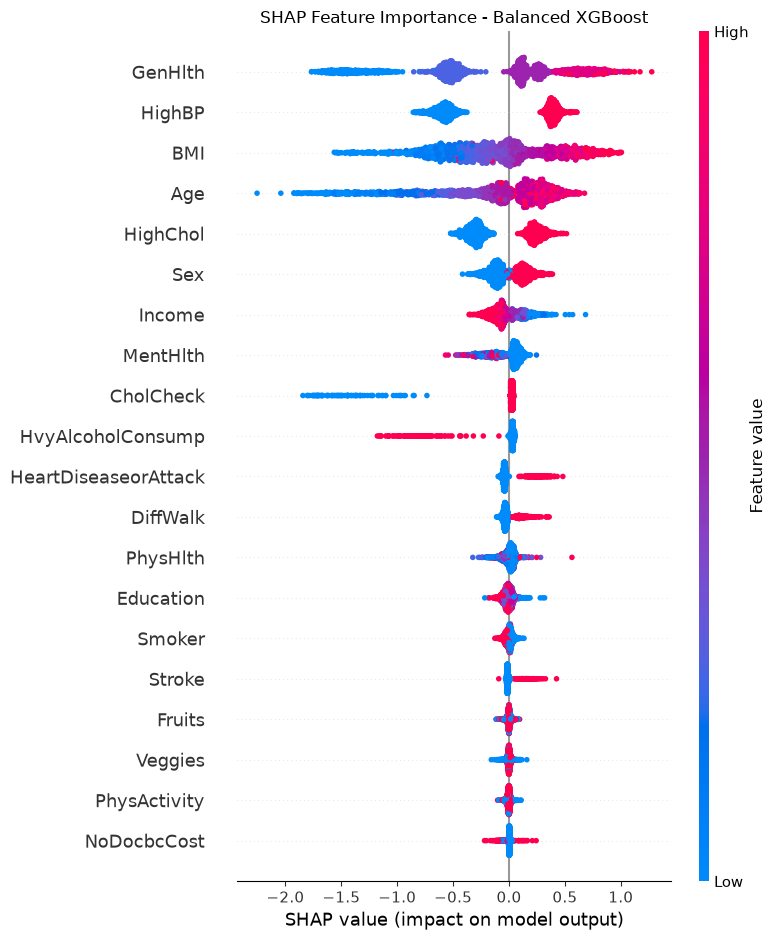

In [23]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test_sample,
    show=False
)

plt.title("SHAP Feature Importance - Balanced XGBoost")
plt.tight_layout()
plt.show()



In [24]:
shap_importance = pd.DataFrame({
    "Feature": X_test_sample.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

shap_importance.head(10)

,Feature,Mean_Absolute_SHAP
13,GenHlth,0.568195
0,HighBP,0.497502
3,BMI,0.407535
18,Age,0.405079
1,HighChol,0.281278
17,Sex,0.128257
20,Income,0.113781
14,MentHlth,0.104678
2,CholCheck,0.083837
10,HvyAlcoholConsump,0.075781


In [25]:
# Select one person from the test set
person_index = 0

person = X_test.iloc[[person_index]]

# Predicted probability
person_probability = xgb_balanced.predict_proba(person)[0, 1]

# Prediction using our chosen threshold
person_prediction = int(person_probability >= 0.65)

print("Predicted probability:", round(person_probability * 100, 2), "%")
print("Prediction:", person_prediction)

Predicted probability: 62.63 %
Prediction: 0


In [26]:
# Calculate SHAP values for this individual
person_shap = explainer.shap_values(person)

print("SHAP values calculated for individual.")

SHAP values calculated for individual.


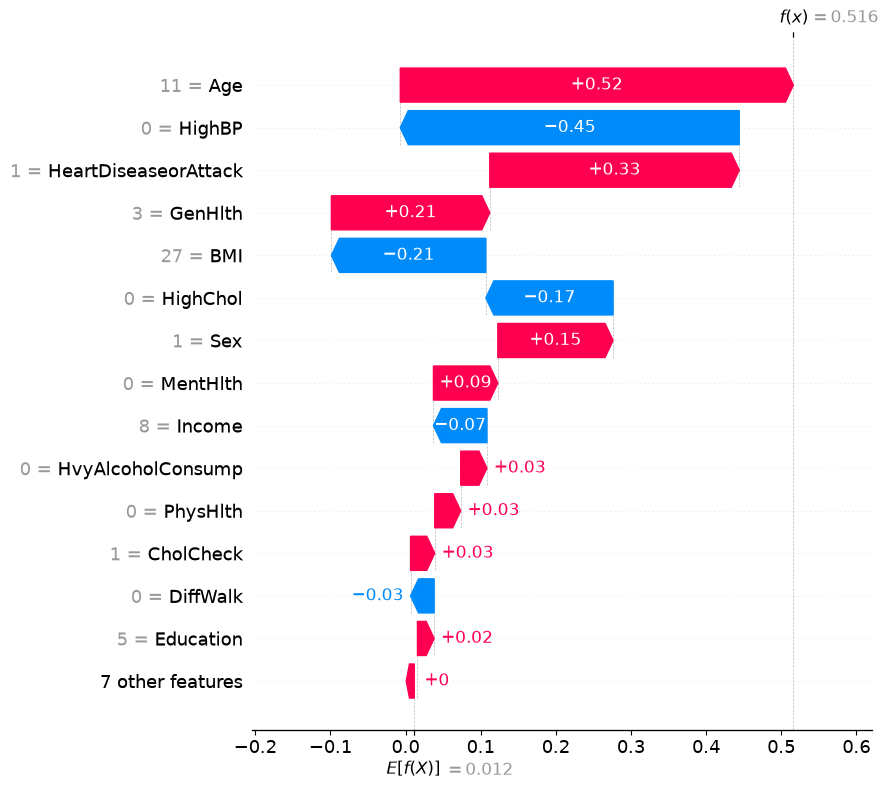

In [27]:
# Create SHAP explanation object for this person

person_explanation = shap.Explanation(
    values=person_shap[0],
    base_values=explainer.expected_value,
    data=person.iloc[0].values,
    feature_names=person.columns.tolist()
)

shap.plots.waterfall(person_explanation, max_display=15)

In [28]:
import joblib

# Save the trained Balanced XGBoost model
joblib.dump(
    xgb_balanced,
    "../models/diabetes_xgb_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [29]:
feature_names = X_train.columns.tolist()

joblib.dump(
    feature_names,
    "../models/feature_names.pkl"
)

print("Feature names saved successfully!")
print(feature_names)

Feature names saved successfully!
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
